Part A: Support Vector Machine (SVM)

1. Load the dataset and perform the necessary preprocessing.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load Breast Cancer Wisconsin Diagnostic Dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columns)

# Display first five rows
print(df.head())

# Check dataset information
print("\nDataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum().sum())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [8]:
# Remove ID column because it is not useful for classification
X = df.drop(columns=["id", "diagnosis"])

# Convert diagnosis into numerical values
# B = 0 (Benign), M = 1 (Malignant)
y = df["diagnosis"].map({"B": 0, "M": 1})

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nClass Distribution:")
print(y.value_counts())


Features Shape: (569, 30)
Target Shape: (569,)

Class Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


2. Split the dataset into training and testing sets in an 80:20 ratio.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (455, 30)
Testing data : (114, 30)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


3. Train an SVM classifier using a Linear Kernel and perform hyperparameter tuning.

In [11]:
svm_model = SVC(kernel="linear", C=1)

svm_model.fit(X_train_scaled, y_train)

# Prediction
y_pred = svm_model.predict(X_test_scaled)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [12]:
# Different values of C to test
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    SVC(kernel="linear"),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 0.01}
Best Cross-Validation Accuracy: 0.9692307692307693


In [13]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

4. Evaluate the model using:

*   Accuracy
*   Precision
*   Recall
*   F1 Score
*   Confusion Matrix

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


In [15]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 1.0


In [16]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.8809523809523809


In [17]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.9367088607594937


In [18]:
print("----- SVM Performance -----")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

----- SVM Performance -----
Accuracy : 0.956140350877193
Precision: 1.0
Recall   : 0.8809523809523809
F1 Score : 0.9367088607594937


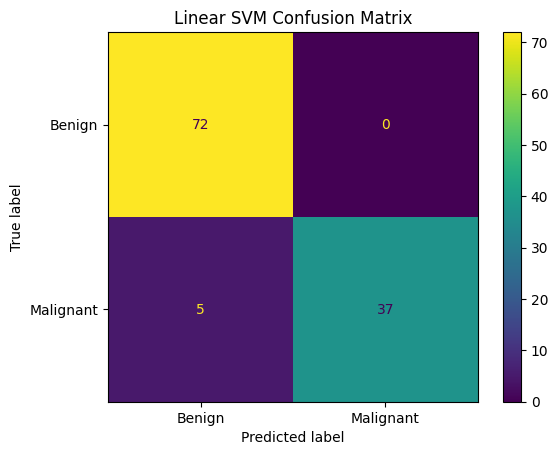

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Linear SVM Confusion Matrix")
plt.show()

5. Summarize your observations.

The Linear SVM classifier achieved high accuracy on the Breast Cancer Wisconsin dataset. Standardization was performed because SVM is sensitive to the scale of features. Hyperparameter tuning was performed using GridSearchCV to find the best value of C. The model was evaluated using accuracy, precision, recall, F1 score, and confusion matrix. The results show that the Linear SVM performs effectively in classifying benign and malignant tumors

Part B: Principal Component Analysis (PCA)

1.	Load the dataset and perform feature standardization.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

# Create DataFrame
df = pd.DataFrame(X, columns=wine.feature_names)

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:", X.shape)

# Feature standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nStandardization completed.")

First 5 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0    

2.	Apply PCA to reduce the dataset from 13 features to 2 principal components.

In [21]:
# Apply PCA with 2 components
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original dataset shape:", X.shape)
print("Transformed dataset shape:", X_pca.shape)

Original dataset shape: (178, 13)
Transformed dataset shape: (178, 2)


3.	Display the explained variance ratio of each principal component.

In [22]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print("PC1:", explained_variance[0])
print("PC2:", explained_variance[1])

print("\nPercentage of variance:")
print("PC1:", explained_variance[0] * 100, "%")
print("PC2:", explained_variance[1] * 100, "%")

print("\nTotal variance retained:",
      explained_variance.sum() * 100, "%")

Explained Variance Ratio:
PC1: 0.3619884809992633
PC2: 0.1920749025700893

Percentage of variance:
PC1: 36.19884809992633 %
PC2: 19.20749025700893 %

Total variance retained: 55.40633835693526 %


4.	Calculate the cumulative explained variance and determine the minimum number of principal components required to retain at least 95% of the total variance.

In [23]:
# Apply PCA with all components
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

# Explained variance ratio
explained_variance_full = pca_full.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_full)

print("Cumulative Explained Variance:")
for i, value in enumerate(cumulative_variance, start=1):
    print(f"PC{i}: {value * 100:.2f}%")

# Minimum components required for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("\nMinimum number of components required for 95% variance:",
      n_components_95)

Cumulative Explained Variance:
PC1: 36.20%
PC2: 55.41%
PC3: 66.53%
PC4: 73.60%
PC5: 80.16%
PC6: 85.10%
PC7: 89.34%
PC8: 92.02%
PC9: 94.24%
PC10: 96.17%
PC11: 97.91%
PC12: 99.20%
PC13: 100.00%

Minimum number of components required for 95% variance: 10


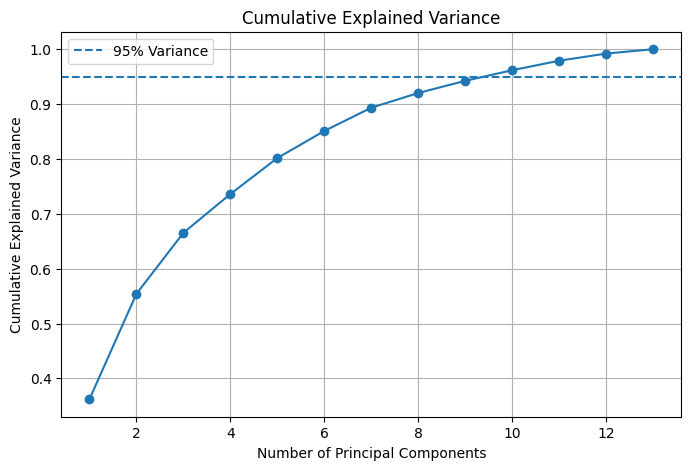

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.95,
    linestyle='--',
    label='95% Variance'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

5.	Visualize the transformed dataset using a two-dimensional scatter plot.

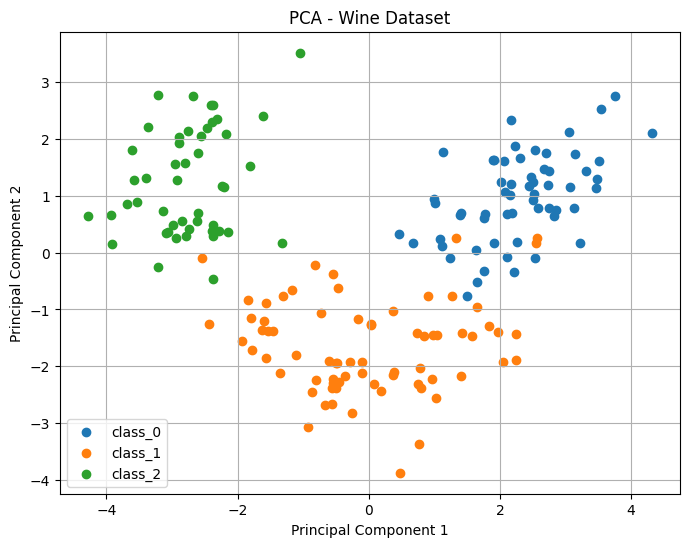

In [25]:
plt.figure(figsize=(8, 6))

# Class 0
plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    label=wine.target_names[0]
)

# Class 1
plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    label=wine.target_names[1]
)

# Class 2
plt.scatter(
    X_pca[y == 2, 0],
    X_pca[y == 2, 1],
    label=wine.target_names[2]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Wine Dataset")
plt.legend()
plt.grid()
plt.show()

6.	Compare the original and transformed datasets in terms of:

o	Number of features

o	Information retained

o	Computational efficiency


In [26]:
print("----- Dataset Comparison -----")

print("Original number of features:", X.shape[1])
print("Transformed number of features:", X_pca.shape[1])

print("\nInformation retained by 2 components:",
      explained_variance.sum() * 100, "%")

print("\nOriginal dimensions:", X.shape)
print("Transformed dimensions:", X_pca.shape)

----- Dataset Comparison -----
Original number of features: 13
Transformed number of features: 2

Information retained by 2 components: 55.40633835693526 %

Original dimensions: (178, 13)
Transformed dimensions: (178, 2)


created a comparison table

In [27]:
comparison = pd.DataFrame({
    "Aspect": [
        "Number of Features",
        "Information Retained",
        "Computational Efficiency"
    ],
    "Original Dataset": [
        13,
        "100%",
        "Higher computational cost"
    ],
    "PCA Dataset": [
        2,
        f"{explained_variance.sum() * 100:.2f}%",
        "Lower computational cost"
    ]
})

print(comparison)

                     Aspect           Original Dataset  \
0        Number of Features                         13   
1      Information Retained                       100%   
2  Computational Efficiency  Higher computational cost   

                PCA Dataset  
0                         2  
1                    55.41%  
2  Lower computational cost  


7.	Interpret the significance of the first two principal components.

In [28]:
# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=wine.feature_names
)

print("PCA Loadings:")
print(loadings)

PCA Loadings:
                                   PC1       PC2
alcohol                       0.144329  0.483652
malic_acid                   -0.245188  0.224931
ash                          -0.002051  0.316069
alcalinity_of_ash            -0.239320 -0.010591
magnesium                     0.141992  0.299634
total_phenols                 0.394661  0.065040
flavanoids                    0.422934 -0.003360
nonflavanoid_phenols         -0.298533  0.028779
proanthocyanins               0.313429  0.039302
color_intensity              -0.088617  0.529996
hue                           0.296715 -0.279235
od280/od315_of_diluted_wines  0.376167 -0.164496
proline                       0.286752  0.364903


In [29]:
print("\nTop features contributing to PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head())

print("\nTop features contributing to PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head())


Top features contributing to PC1:
flavanoids                      0.422934
total_phenols                   0.394661
od280/od315_of_diluted_wines    0.376167
proanthocyanins                 0.313429
nonflavanoid_phenols            0.298533
Name: PC1, dtype: float64

Top features contributing to PC2:
color_intensity    0.529996
alcohol            0.483652
proline            0.364903
ash                0.316069
magnesium          0.299634
Name: PC2, dtype: float64


8.	Discuss the advantages, limitations, and applications of PCA in machine learning.

Advantages:

1.	Reduces the number of features.
2.	Reduces computational complexity.
3.	Helps visualize high-dimensional data.
4.	Removes redundant information from correlated features.
5.	Can help reduce noise.

Limitations:

1.	Some information may be lost.
2.	Principal components can be difficult to interpret.
3.	PCA is sensitive to feature scaling.
4.	PCA does not use class labels.
5.	Maximum variance does not always mean maximum class separation.

Applications:

1.	Image processing.
2.	Data visualization.
3.	Feature extraction.
4.	Pattern recognition.
5.	Machine learning preprocessing.
6.	Noise reduction.
7.	Bioinformatics.



9.	Apply Linear Discriminant Analysis (LDA) to the same dataset and reduce it to two linear discriminants.

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Apply LDA with 2 components
lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_scaled, y)

print("Original dataset shape:", X.shape)
print("LDA transformed shape:", X_lda.shape)

Original dataset shape: (178, 13)
LDA transformed shape: (178, 2)


10.	Visualize the transformed LDA data and compare PCA and LDA in terms of dimensionality reduction and class separability.

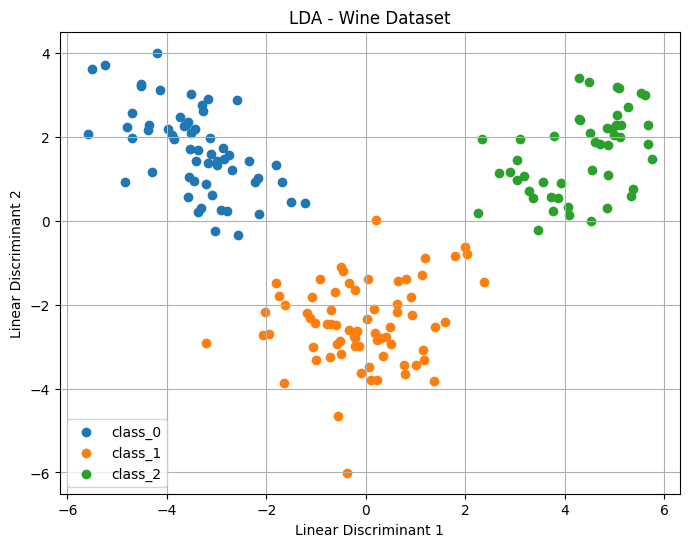

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_lda[y == 0, 0],
    X_lda[y == 0, 1],
    label=wine.target_names[0]
)

plt.scatter(
    X_lda[y == 1, 0],
    X_lda[y == 1, 1],
    label=wine.target_names[1]
)

plt.scatter(
    X_lda[y == 2, 0],
    X_lda[y == 2, 1],
    label=wine.target_names[2]
)

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("LDA - Wine Dataset")
plt.legend()
plt.grid()
plt.show()

In [32]:
print("----- PCA vs LDA -----")

print("Original features:", X.shape[1])
print("PCA features:", X_pca.shape[1])
print("LDA features:", X_lda.shape[1])

print("\nPCA: Unsupervised dimensionality reduction")
print("LDA: Supervised dimensionality reduction")

print("\nPCA focuses on maximum variance.")
print("LDA focuses on maximum class separability.")

----- PCA vs LDA -----
Original features: 13
PCA features: 2
LDA features: 2

PCA: Unsupervised dimensionality reduction
LDA: Supervised dimensionality reduction

PCA focuses on maximum variance.
LDA focuses on maximum class separability.


11.	Summarize your observations.

PCA reduced the Wine dataset from 13 features to 2 principal components, making the dataset easier to visualize and reducing computational complexity. The first two principal components retained approximately 55% of the total variance. More principal components were required to retain at least 95% of the total variance. LDA also reduced the dataset to two dimensions, but unlike PCA, it used class labels and focused on maximizing class separability. Therefore, PCA is useful for general dimensionality reduction, while LDA is more suitable when class separation is important